In [14]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

In [25]:
#Data (We use log returns)
data = yf.download('SPY', start='2005-01-01', end='2025-01-01', auto_adjust=True)
close = data['Close'].squeeze()
returns = np.log(close / close.shift(1)).dropna()

rolling_vol = returns.rolling(20).std()

#Rolling volatility (20 day window)
features = pd.DataFrame({
    'returns': returns,
    'volatility': rolling_vol
}).dropna()

print(f"Data loaded: {len(features)} trading days")
print(features.head())

[*********************100%***********************]  1 of 1 completed

Data loaded: 5013 trading days
             returns  volatility
Date                            
2005-02-01  0.006327    0.006442
2005-02-02  0.003023    0.005860
2005-02-03 -0.002602    0.005660
2005-02-04  0.010619    0.006025
2005-02-07 -0.001332    0.006023


In [26]:
split = int(len(features) * 0.8)

#iloc = integer locate
train_features = features.iloc[:split]
test_features = features.iloc[split:]

print(f"Train: {len(train_features)} days")
print(f"Test:  {len(test_features)} days")

Train: 4010 days
Test:  1003 days


In [27]:
# RobustScaler is better for financial data — resistant to outliers like crash days
scaler = RobustScaler()
scaled_train = scaler.fit_transform(train_features)

model = GaussianHMM(n_components=3, covariance_type="full", n_iter=200, random_state=42)
model.fit(scaled_train)

print(f"Converged: {model.monitor_.converged}")

Converged: True


In [ ]:
# Scale full dataset using train scaler
all_scaled = scaler.transform(features.values)
states = model.predict(all_scaled)

# Label states by mean return
state_means = [features['returns'].values[states == s].mean() for s in range(3)]
sorted_states = np.argsort(state_means)
state_labels = {sorted_states[0]: 'Bearish', sorted_states[1]: 'Neutral', sorted_states[2]: 'Bullish'}
colors = {sorted_states[0]: '#d62728', sorted_states[1]: '#aec7e8', sorted_states[2]: '#2ca02c'}

print("State means:", {state_labels[s]: f"{state_means[s]:.4f}" for s in range(3)})

State means: {'Bullish': '0.0007', 'Neutral': '0.0004', 'Bearish': '-0.0008'}


c:\Users\Robert\IPOT\hmm-regime-detection\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


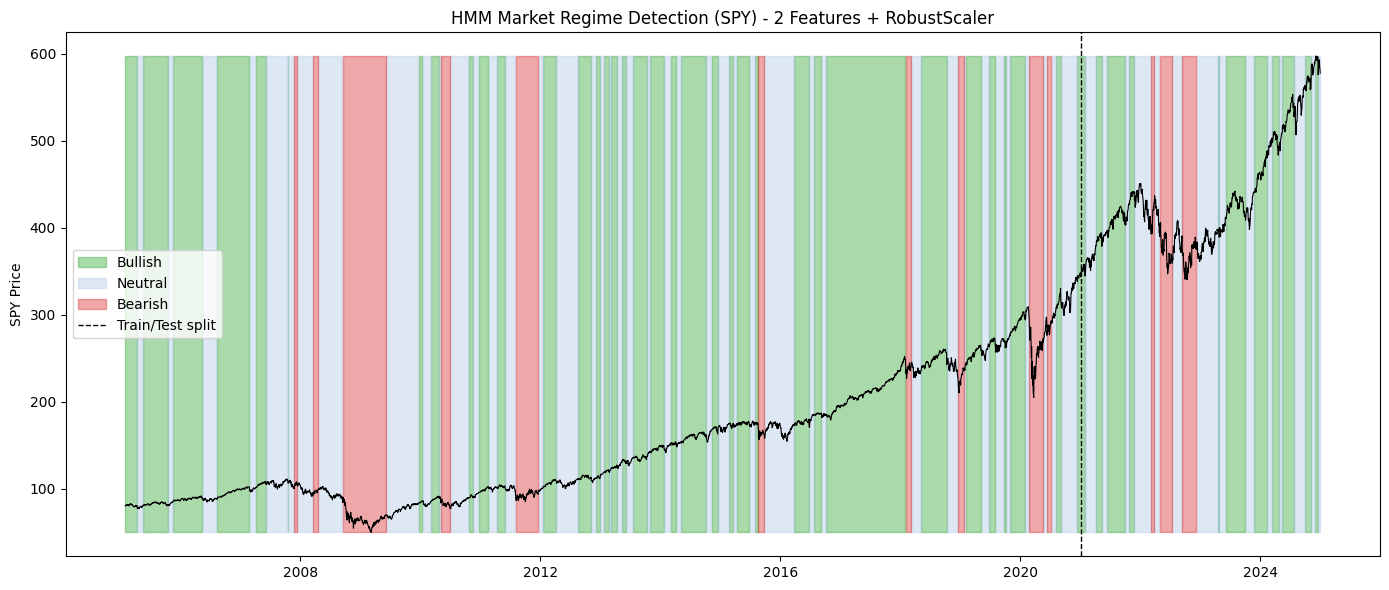

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(features.index, close.loc[features.index], color='black', linewidth=0.8, zorder=3)

for state in range(3):
    mask = (states == state)
    plt.fill_between(features.index,
                     close.loc[features.index].min(),
                     close.loc[features.index].max(),
                     where=mask, alpha=0.4, color=colors[state],
                     label=state_labels[state], zorder=1)

split_date = features.index[split]
plt.axvline(split_date, color='black', linestyle='--', linewidth=1, label='Train/Test split')
plt.legend()
plt.title('HMM Market Regime Detection (SPY) - 2 Features + RobustScaler')
plt.ylabel('SPY Price')
plt.tight_layout()
plt.show()

In [30]:
for state in range(3):
    regime_returns = features['returns'].values[states == state]
    print(f"{state_labels[state]:8s} | Mean: {regime_returns.mean():.4f} | Std: {regime_returns.std():.4f} | Days: {len(regime_returns)}")

Bullish  | Mean: 0.0007 | Std: 0.0057 | Days: 2289
Neutral  | Mean: 0.0004 | Std: 0.0106 | Days: 2097
Bearish  | Mean: -0.0008 | Std: 0.0257 | Days: 627
